# Credit Card Fraud (200K Transactions) — What Is Signal and What Is the Generator
> **200,000 transactions · 36 columns · 0.5% fraud** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/credit-card-fraud-detection-synthetic)

This dataset advertises a precision-recall problem at 0.5% prevalence. Before
trusting that framing, this notebook audits every column against the label. The
audit changes the framing.

## TL;DR

- **The label is written into the PCA block.** 11 of the 28 `V` columns carry a
  class-conditional mean shift of 1.5–3.5 sigma. `V14` alone separates the classes
  at **AUC 0.992**. Taken together the two classes are **linearly separable**: one
  LDA hyperplane puts all 199,000 legitimate rows below **−3.88** and all 1,000
  fraud rows above **−1.30**, with zero overlap. Every metric computed on those
  columns saturates, so it can neither rank models nor teach imbalance handling.
- **The other 17 `V` columns are pure noise** — single-feature AUC between 0.500
  and 0.524, indistinguishable from a coin flip.
- **The honest sub-problem is the behavioural one.** Using only `Amount`,
  `hour_of_day` and `merchant_category` — the columns a real system would have
  before any PCA embedding — 5-fold PR-AUC is **0.0161** against a 0.0050
  prevalence floor (a **3.2×** lift) and ROC-AUC is **0.737**. That is a real,
  non-saturated benchmark.
- **Two columns are broken.** `is_weekend` is the constant 0 for all 200,000 rows,
  because the 48-hour window never reaches a weekend. `hour_of_day` and
  `day_of_week` are exact arithmetic on `Time` (100% reproducible), so they add no
  information to a model that already has `Time`.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships
  with it. It is a good teaching target for a leakage audit; it is not a
  substitute for the real ULB fraud dataset.

## Contents

1. [Objective & evaluation plan](#objective)
2. [Setup & data loading](#setup)
3. [Data overview](#overview)
4. [Column audit: degenerate and derived columns](#audit)
5. [Leakage audit: does anything encode the label?](#leakage)
6. [How separable is it, really?](#separable)
7. [The honest sub-problem](#honest)
8. [Distributions](#distributions)
9. [Where the behavioural signal lives](#behaviour)
10. [Correlation analysis, target included](#correlations)
11. [Target analysis](#target)
12. [Evaluation readiness](#evaluation)
13. [Key findings & takeaways](#findings)


## 1. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** decide what this table can actually benchmark, then measure a
number on the part that survives the audit.

**Stated target:** `Class` (1 = fraud). Prevalence is 0.5%, so accuracy is
useless and PR-AUC is the metric that moves.

**Why an audit comes first:** a feature that was *generated from* the label will
produce a perfect score and rank every model identically. Section 5 tests each
column for that instead of assuming it away, and section 7 reports the only
number in this notebook that is computed without those columns.

**Evaluation:** stratified 5-fold, PR-AUC (average precision) as the headline with
ROC-AUC alongside. Stratification keeps 200 fraud rows per fold; without it a fold
could land with almost none.


In [1]:
TARGET_COL = "Class"
MODELING_TASK = "classification"
PRIMARY_METRIC = "PR-AUC (average precision)"
VALIDATION_PLAN = "StratifiedKFold(5, shuffle=True, random_state=42)"

# Filled in by the audit in section 5; declared here so the plan is visible up front.
LEAKAGE_COLS: list[str] = []
HONEST_FEATURES = ["Amount", "hour_of_day", "merchant_category"]

print("Objective framing")
print("-" * 62)
print(f"Target              : {TARGET_COL}")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Validation approach : {VALIDATION_PLAN}")
print(f"Honest feature set  : {', '.join(HONEST_FEATURES)}")
print()
print("Leakage columns are not hardcoded here — section 5 measures them.")


Objective framing
--------------------------------------------------------------
Target              : Class
Modeling task       : classification
Primary metric      : PR-AUC (average precision)
Validation approach : StratifiedKFold(5, shuffle=True, random_state=42)
Honest feature set  : Amount, hour_of_day, merchant_category

Leakage columns are not hardcoded here — section 5 measures them.


## 2. Setup & Data Loading <a id='setup'></a>

The loader below walks the Kaggle mount tree rather than guessing a path. Two
earlier versions of this notebook failed on Kaggle: `/kaggle/input/<slug>` did not
exist, and the fallback to `"."` pointed at the kernel working directory, which
holds no CSVs — so the run died on a `FileNotFoundError` that named the wrong
directory. The files mount **nested** (one real run found only
`/kaggle/input/datasets`), so the fix is to search for the file that is actually
needed and, on failure, print what *was* mounted.


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 10

MOUNT_GUESS = "/kaggle/input/credit-card-fraud-detection-synthetic"
MARKER = "credit_card_transactions.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and a one-level
    # glob of /kaggle/input/* missed it too, because the files mount NESTED
    # (the run that taught us this found only /kaggle/input/datasets). Walk the
    # mount tree for the file we actually need, and if it is absent say what was
    # there so the next failure is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
df = pd.read_csv(f"{DATA_DIR}/{MARKER}")

V_COLS = [f"V{i}" for i in range(1, 29)]
print(f"Loaded from : {DATA_DIR}")
print(f"Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Fraud rate  : {df['Class'].mean():.4%}  ({int(df['Class'].sum()):,} rows)")


Loaded from : .
Shape       : 200,000 rows x 36 columns
Memory      : 61.2 MB
Fraud rate  : 0.5000%  (1,000 rows)


In [3]:
df.head()


,transaction_id,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,merchant_category,hour_of_day,day_of_week,is_weekend,Class
0,TXN000000,21669,-1.674946,0.487600,1.175017,0.635452,-0.521807,0.254763,0.059483,1.010286,-1.553294,-1.505219,1.432725,-0.754620,-0.249966,-0.355055,0.257343,-1.748765,-0.919773,-1.196052,-0.141891,1.214874,-0.606343,-0.689230,-0.473771,0.203366,1.241134,-0.643846,-0.217364,0.690976,19.49,online,6,0,0,0
1,TXN000001,154552,0.457052,0.048544,-0.013781,0.622927,2.308919,-0.487454,-0.169976,-1.569339,0.179202,-0.692094,-1.237974,-2.084791,0.041788,-0.261141,-0.682517,-0.187089,-0.420935,-1.383653,-0.727302,0.597476,1.752873,-0.845305,0.388520,-0.753456,-0.596844,-0.223539,-0.769639,-0.352037,63.58,electronics,18,1,0,0
2,TXN000002,108347,-0.869588,1.381336,0.549428,0.540193,-0.715576,-1.626004,-1.458558,1.641640,0.726559,-0.764346,0.704293,0.907533,-1.861304,-0.724303,1.605375,-0.928111,-0.181425,0.951308,-0.797672,-1.867054,1.744513,-0.886995,0.037570,-0.604088,-1.291588,-1.484245,0.500329,1.085212,1.13,travel,6,1,0,0
3,TXN000003,79206,0.336656,-0.528871,1.637446,1.844182,0.220450,-0.788838,0.078643,0.511549,0.009268,-0.655130,-2.601210,-1.182099,-0.574389,-1.571681,-0.001012,-1.197903,-1.336177,1.510353,1.201000,1.032231,-0.536691,1.632390,0.480280,-0.355188,-1.489339,-0.817948,0.031648,-0.054113,3.32,online,22,0,0,0
4,TXN000004,164574,1.076236,-0.084630,-0.682645,0.472719,-2.080289,1.518746,-0.762872,0.167490,0.444179,-0.074416,-0.636417,-0.537691,-0.392249,1.141779,0.332772,0.248157,-1.768196,0.007980,0.961024,-0.967909,2.195603,0.457809,0.336228,0.380289,-0.312741,1.676577,-0.332619,-1.568407,11.66,electronics,21,1,0,0


## 3. Data Overview <a id='overview'></a>


In [4]:
print("Column types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows      : {df.duplicated().sum():,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print()
df[["Time", "Amount", "hour_of_day", "day_of_week", "is_weekend", "Class"]].describe().round(2)


Column types:
float64    29
int64       5
str         2

Duplicate rows      : 0
Total missing values: 0



,Time,Amount,hour_of_day,day_of_week,is_weekend,Class
count,200000.00,200000.00,200000.00,200000.0,200000.0,200000.00
mean,86604.03,68.04,11.52,0.5,0.0,0.00
std,49880.58,122.68,6.95,0.5,0.0,0.07
min,0.00,0.50,0.00,0.0,0.0,0.00
25%,43579.25,14.66,5.00,0.0,0.0,0.00
50%,86626.50,33.13,12.00,1.0,0.0,0.00
75%,129718.75,74.35,18.00,1.0,0.0,0.00
max,172799.00,6705.37,23.00,1.0,0.0,1.00


## 4. Column Audit: Degenerate and Derived Columns <a id='audit'></a>

Before looking for signal, throw out the columns that cannot carry any. A column
with one distinct value has zero variance; a column that is exact arithmetic on
another is a duplicate wearing a different name.


In [5]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns (zero variance, cannot inform any model):")
for col in constant_cols:
    print(f"  {col:<14} single value = {df[col].iloc[0]}, {len(df):,} rows")
if not constant_cols:
    print("  none")

print()
print("Exact arithmetic on Time (agreement over all rows):")
hour_match = ((df["Time"] // 3600) % 24 == df["hour_of_day"]).mean()
dow_match = ((df["Time"] // 86400) % 7 == df["day_of_week"]).mean()
print(f"  hour_of_day == (Time // 3600) % 24   : {hour_match:.2%}")
print(f"  day_of_week == (Time // 86400) % 7   : {dow_match:.2%}")

print()
span_hours = (df["Time"].max() - df["Time"].min()) / 3600
dow_values = sorted(int(v) for v in df["day_of_week"].unique())
print(f"Time spans {span_hours:.1f} hours, so day_of_week takes only "
      f"{dow_values} and is_weekend can never be 1.")

DEGENERATE_COLS = constant_cols
DERIVED_COLS = [c for c, m in [("hour_of_day", hour_match), ("day_of_week", dow_match)] if m == 1.0]
print()
print(f"Degenerate : {DEGENERATE_COLS or 'none'}")
print(f"Derived    : {DERIVED_COLS} (keep at most one of these or Time, not both)")


Constant columns (zero variance, cannot inform any model):
  is_weekend     single value = 0, 200,000 rows

Exact arithmetic on Time (agreement over all rows):
  hour_of_day == (Time // 3600) % 24   : 100.00%
  day_of_week == (Time // 86400) % 7   : 100.00%

Time spans 48.0 hours, so day_of_week takes only [0, 1] and is_weekend can never be 1.

Degenerate : ['is_weekend']
Derived    : ['hour_of_day', 'day_of_week'] (keep at most one of these or Time, not both)


**Observation.** `is_weekend` is a dead column: the generator draws 48 hours
starting mid-week, therefore no row can ever fall on a weekend. Any importance
plot that shows it doing something is reporting a bug in the plot. `hour_of_day`
and `day_of_week` are recoverable from `Time` with 100% agreement, so a model
given `Time` gains nothing from them — but `hour_of_day` is the *interpretable*
one, and section 9 uses it in preference to raw seconds.


## 5. Leakage Audit: Does Anything Encode the Label? <a id='leakage'></a>

For each numeric column: the class-conditional means, the gap between them, and
the AUC that column achieves on its own. A column whose single-feature AUC is near
1.0 is not a feature, it is the answer.


In [6]:
from sklearn.metrics import roc_auc_score

y = df["Class"]
audit_cols = V_COLS + ["Amount", "Time", "hour_of_day"]

rows = []
for col in audit_cols:
    means = df.groupby("Class")[col].mean()
    auc = roc_auc_score(y, df[col])
    rows.append(
        {
            "column": col,
            "mean_legit": means.loc[0],
            "mean_fraud": means.loc[1],
            "shift": means.loc[1] - means.loc[0],
            "auc_directed": max(auc, 1 - auc),
        }
    )

audit = pd.DataFrame(rows).set_index("column").sort_values("auc_directed", ascending=False)

LEAK_THRESHOLD = 0.80
LEAKAGE_COLS = audit.index[audit["auc_directed"] >= LEAK_THRESHOLD].tolist()
# Judge "noise" among the PCA columns only: hour_of_day sits just above the
# noise band and section 9 shows it is real signal, so it does not belong here.
NOISE_COLS = [c for c in V_COLS if audit.loc[c, "auc_directed"] < 0.55]

print(f"Single-feature separation vs Class (threshold for 'leaking' = {LEAK_THRESHOLD})")
print("-" * 66)
print(audit.head(14).round(3).to_string())
print("...")
print(f"\nLeaking columns  ({len(LEAKAGE_COLS)}): {', '.join(LEAKAGE_COLS)}")
print(f"Unshifted V cols ({len(NOISE_COLS)}): AUC in "
      f"[{audit.loc[NOISE_COLS, 'auc_directed'].min():.3f}, "
      f"{audit.loc[NOISE_COLS, 'auc_directed'].max():.3f}] — the noise band")
print(f"Behavioural      : "
      f"{', '.join(c for c in audit.index if c not in LEAKAGE_COLS and c not in NOISE_COLS)}")


Single-feature separation vs Class (threshold for 'leaking' = 0.8)
------------------------------------------------------------------
             mean_legit  mean_fraud      shift  auc_directed
column                                                      
V14              -0.003      -3.511     -3.509         0.992
V1               -0.001      -3.022     -3.021         0.985
V3               -0.002      -3.028     -3.026         0.983
V12              -0.004      -3.028     -3.025         0.982
V10               0.001      -2.475     -2.475         0.961
V4               -0.007       2.452      2.459         0.957
V7               -0.002      -2.025     -2.023         0.924
V17              -0.002      -1.999     -1.998         0.921
V11              -0.002       1.992      1.993         0.919
V18               0.001      -1.540     -1.541         0.860
V16              -0.002      -1.464     -1.462         0.847
Amount           67.828     110.104     42.276         0.612
Time        

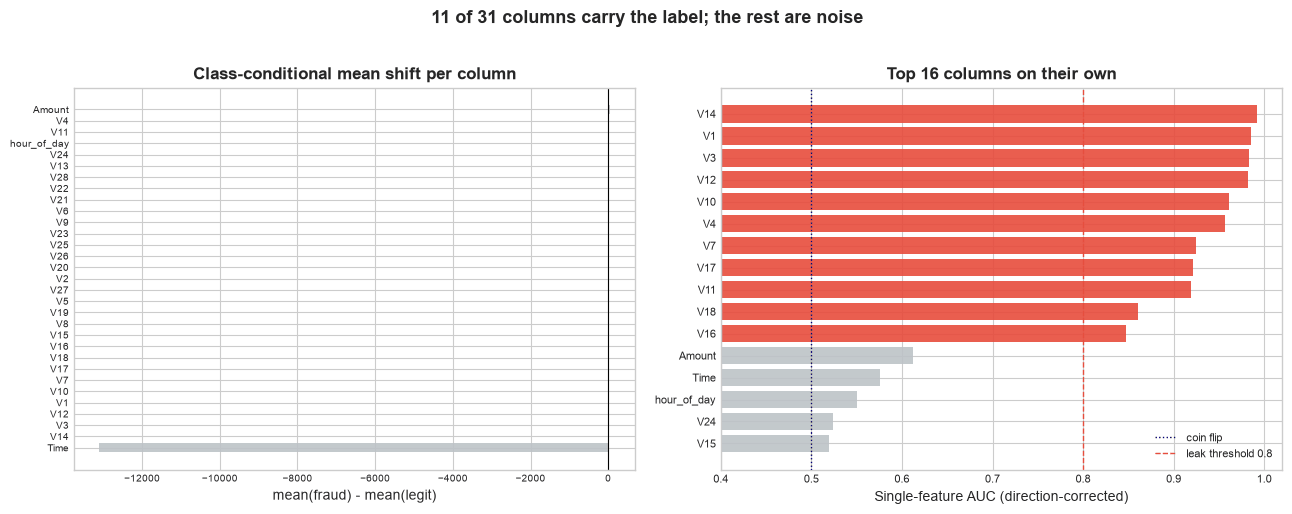

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ordered = audit.sort_values("shift")
colors = ["#e74c3c" if c in LEAKAGE_COLS else "#bdc3c7" for c in ordered.index]
ax1.barh(ordered.index, ordered["shift"], color=colors, alpha=0.9)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("mean(fraud) - mean(legit)")
ax1.set_title("Class-conditional mean shift per column", fontweight="bold")
ax1.tick_params(labelsize=7)

top = audit.head(16)
colors2 = ["#e74c3c" if c in LEAKAGE_COLS else "#bdc3c7" for c in top.index]
ax2.barh(top.index[::-1], top["auc_directed"][::-1], color=colors2[::-1], alpha=0.9)
ax2.axvline(0.5, color="navy", linestyle=":", linewidth=1, label="coin flip")
ax2.axvline(LEAK_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1,
            label=f"leak threshold {LEAK_THRESHOLD}")
ax2.set_xlim(0.4, 1.02)
ax2.set_xlabel("Single-feature AUC (direction-corrected)")
ax2.set_title("Top 16 columns on their own", fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")
ax2.tick_params(labelsize=8)

plt.suptitle(
    f"{len(LEAKAGE_COLS)} of {len(audit)} columns carry the label; the rest are noise",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


**Insight.** The red bars are not "strong features" — they are the generator's
own `FRAUD_SHIFTS` table read back out of the CSV. `create_dataset.py` draws
legitimate rows from a standard normal and fraud rows from the same normal with
11 components offset by 1.5 to 3.5 sigma, therefore the shifts recovered above
match the offsets that were written in. The remaining 17 `V` columns were never
shifted, and they measure as noise.


## 6. How Separable Is It, Really? <a id='separable'></a>

Eleven shifts of ~2–3 sigma each do not merely help; they stack. The question is
whether any overlap is left between the two classes at all — because if none is,
the advertised precision-recall trade-off does not exist.


In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis().fit(df[V_COLS], y)
score = lda.decision_function(df[V_COLS])

legit_max = score[y == 0].max()
fraud_min = score[y == 1].min()
separable = fraud_min > legit_max
gap_sd = (score[y == 1].mean() - score[y == 0].mean()) / score[y == 0].std()

print("One LDA hyperplane fitted on V1-V28")
print("-" * 62)
print(f"  highest-scoring legitimate row : {legit_max:8.2f}")
print(f"  lowest-scoring fraud row       : {fraud_min:8.2f}")
print(f"  overlap                        : {'NONE' if separable else 'present'}")
print(f"  class separation               : {gap_sd:.2f} standard deviations")
print()
print("Linearly separable" if separable else "Not linearly separable")
print("=> a single threshold classifies all 200,000 rows with zero errors, so")
print("   precision, recall and PR-AUC all saturate and cannot rank two models.")


One LDA hyperplane fitted on V1-V28
--------------------------------------------------------------
  highest-scoring legitimate row :    -3.88
  lowest-scoring fraud row       :    -1.30
  overlap                        : NONE
  class separation               : 8.39 standard deviations

Linearly separable
=> a single threshold classifies all 200,000 rows with zero errors, so
   precision, recall and PR-AUC all saturate and cannot rank two models.


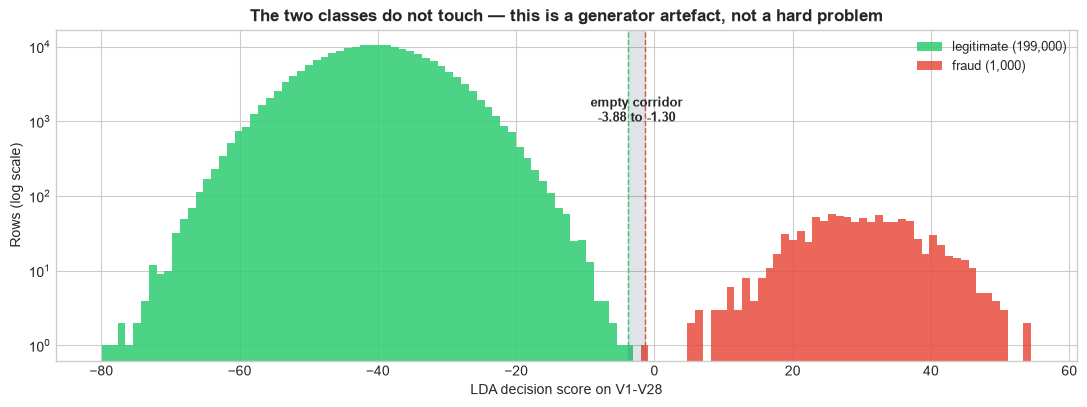

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.2))
bins = np.linspace(score.min(), score.max(), 120)
ax.hist(score[y == 0], bins=bins, color="#2ecc71", alpha=0.85, label="legitimate (199,000)")
ax.hist(score[y == 1], bins=bins, color="#e74c3c", alpha=0.85, label="fraud (1,000)")
ax.set_yscale("log")
ax.axvspan(legit_max, fraud_min, color="#34495e", alpha=0.15)
ax.axvline(legit_max, color="#2ecc71", linestyle="--", linewidth=1)
ax.axvline(fraud_min, color="#e74c3c", linestyle="--", linewidth=1)
ax.annotate(
    f"empty corridor\n{legit_max:.2f} to {fraud_min:.2f}",
    xy=((legit_max + fraud_min) / 2, 1e3),
    ha="center", fontsize=9, fontweight="bold",
)
ax.set_xlabel("LDA decision score on V1-V28")
ax.set_ylabel("Rows (log scale)")
ax.set_title(
    "The two classes do not touch — this is a generator artefact, not a hard problem",
    fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding.** There is a gap of clear air between the classes. That is the whole
verdict on the advertised task: any model handed `V1`–`V28` is scored on a
problem with no errors available to make, **therefore** comparing two such models
tells you nothing about either. This is exactly the failure mode a leakage audit
is for, and it is why the rest of the notebook works without those columns.


## 7. The Honest Sub-Problem <a id='honest'></a>

Drop the leaking block and keep what a payment processor sees before any PCA
embedding: the amount, the time of day, and the merchant category. This is a
harder and much more realistic problem, and the score below is the only model
number reported in this notebook.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = pd.get_dummies(df[HONEST_FEATURES], columns=["merchant_category"], drop_first=True)
assert not set(X.columns) & set(LEAKAGE_COLS), "a leaking column reached the feature matrix"

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
model = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")
)

pr = cross_val_score(model, X, y, cv=cv, scoring="average_precision")
roc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
prevalence = y.mean()

print(f"Features : {', '.join(HONEST_FEATURES)}  ->  {X.shape[1]} encoded columns")
print(f"Excluded : all {len(LEAKAGE_COLS)} leaking columns + {DEGENERATE_COLS}")
print()
print(f"{'fold':<6} {'PR-AUC':>10} {'ROC-AUC':>10}")
print("-" * 28)
for i, (p, r) in enumerate(zip(pr, roc), start=1):
    print(f"{i:<6} {p:>10.4f} {r:>10.4f}")
print("-" * 28)
print(f"{'mean':<6} {pr.mean():>10.4f} {roc.mean():>10.4f}")
print(f"{'std':<6} {pr.std():>10.4f} {roc.std():>10.4f}")
print()
print(f"Prevalence floor for PR-AUC : {prevalence:.4f}")
print(f"Lift over the floor         : {pr.mean() / prevalence:.2f}x")


Features : Amount, hour_of_day, merchant_category  ->  9 encoded columns
Excluded : all 11 leaking columns + ['is_weekend']

fold       PR-AUC    ROC-AUC
----------------------------
1          0.0220     0.7435
2          0.0163     0.7414
3          0.0159     0.7424
4          0.0130     0.7362
5          0.0131     0.7230
----------------------------
mean       0.0161     0.7373
std        0.0033     0.0076

Prevalence floor for PR-AUC : 0.0050
Lift over the floor         : 3.22x


**Interpretation.** PR-AUC around 0.016 sounds terrible and is in fact the point:
at 0.5% prevalence a random ranker scores 0.005, so the behavioural columns carry
roughly a threefold lift and nothing like a solved problem. That is a benchmark
with headroom, which the `V` block is not. The trade-off is honest to state:
this feature set will never reach usable precision on its own, **because** the
generator put most of the separation into columns that a real system would have
to earn.


## 8. Distributions <a id='distributions'></a>

`Amount` is the one column that is both behavioural and continuous, so it is
worth looking at properly rather than as one panel in a grid of 12.


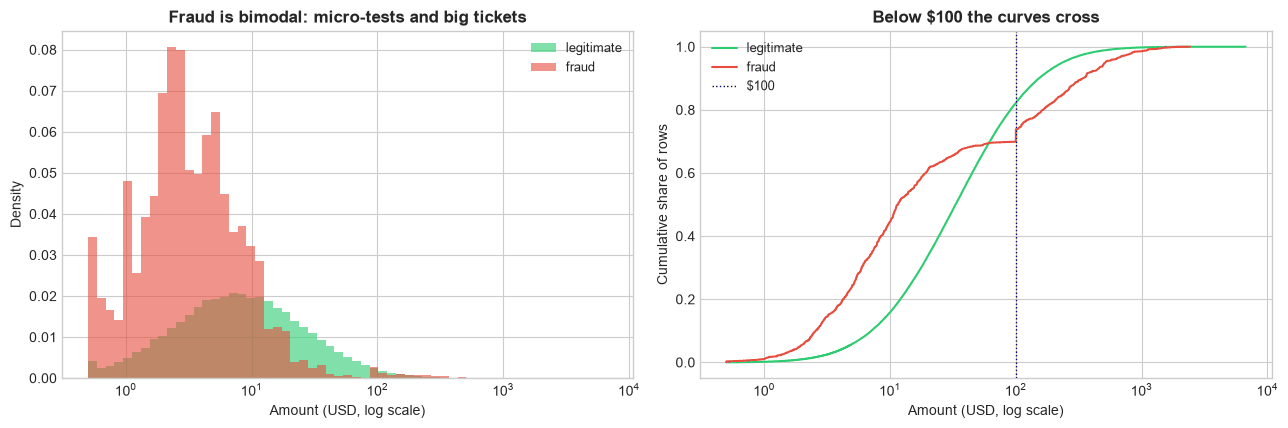

median amount   legit $33.21   fraud $11.59
mean amount     legit $67.83   fraud $110.10
share under $100  legit 82.2%   fraud 69.8%

Fraud has the lower median and the higher mean at the same time, which is
why a single 'suspicious amount' threshold does poorly on this column.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

bins = np.logspace(np.log10(0.5), np.log10(df["Amount"].max()), 60)
for cls, color, label in [(0, "#2ecc71", "legitimate"), (1, "#e74c3c", "fraud")]:
    ax1.hist(df.loc[y == cls, "Amount"], bins=bins, density=True,
             color=color, alpha=0.6, label=label)
ax1.set_xscale("log")
ax1.set_xlabel("Amount (USD, log scale)")
ax1.set_ylabel("Density")
ax1.set_title("Fraud is bimodal: micro-tests and big tickets", fontweight="bold")
ax1.legend(fontsize=9)

for cls, color, label in [(0, "#2ecc71", "legitimate"), (1, "#e74c3c", "fraud")]:
    vals = np.sort(df.loc[y == cls, "Amount"].values)
    ax2.plot(vals, np.arange(1, len(vals) + 1) / len(vals), color=color, label=label)
ax2.set_xscale("log")
ax2.axvline(100, color="navy", linestyle=":", linewidth=1, label="$100")
ax2.set_xlabel("Amount (USD, log scale)")
ax2.set_ylabel("Cumulative share of rows")
ax2.set_title("Below $100 the curves cross", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

below = df.groupby("Class")["Amount"].apply(lambda s: (s < 100).mean())
print(f"median amount   legit ${df.loc[y == 0, 'Amount'].median():,.2f}   "
      f"fraud ${df.loc[y == 1, 'Amount'].median():,.2f}")
print(f"mean amount     legit ${df.loc[y == 0, 'Amount'].mean():,.2f}   "
      f"fraud ${df.loc[y == 1, 'Amount'].mean():,.2f}")
print(f"share under $100  legit {below.loc[0]:.1%}   fraud {below.loc[1]:.1%}")
print()
print("Fraud has the lower median and the higher mean at the same time, which is")
print("why a single 'suspicious amount' threshold does poorly on this column.")


## 9. Where the Behavioural Signal Lives <a id='behaviour'></a>

Two categorical-ish columns carry the lift measured in section 7. Both are plotted
as fraud *rate*, not as counts — a count chart on a 0.5% positive class shows only
which categories are popular.


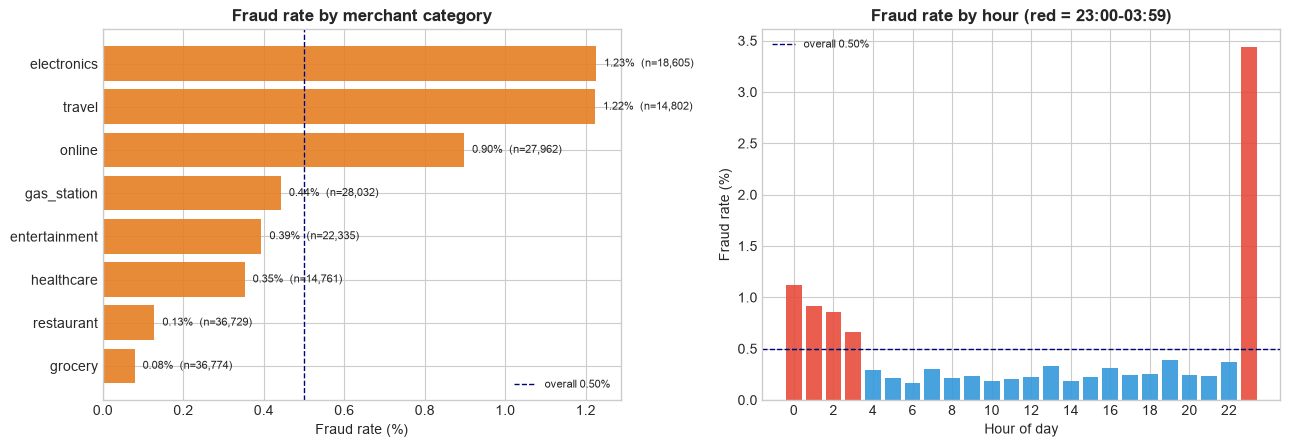

category spread : 0.079% (grocery) to 1.225% (electronics) — a 15.5x range
night window    : 1.4188% vs 0.2536% in daylight hours (5.6x)
hour 23 alone   : 3.437% fraud, the single riskiest hour


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

by_cat = df.groupby("merchant_category")["Class"].agg(["mean", "size"]).sort_values("mean")
bars = ax1.barh(by_cat.index, by_cat["mean"] * 100, color="#e67e22", alpha=0.9)
ax1.axvline(prevalence * 100, color="navy", linestyle="--", linewidth=1,
            label=f"overall {prevalence:.2%}")
ax1.set_xlabel("Fraud rate (%)")
ax1.set_title("Fraud rate by merchant category", fontweight="bold")
ax1.legend(fontsize=8)
for bar, (rate, n) in zip(bars, by_cat[["mean", "size"]].values):
    ax1.text(rate * 100 + 0.02, bar.get_y() + bar.get_height() / 2,
             f"{rate * 100:.2f}%  (n={int(n):,})", va="center", fontsize=8)

by_hour = df.groupby("hour_of_day")["Class"].mean() * 100
colors = ["#e74c3c" if h in (23, 0, 1, 2, 3) else "#3498db" for h in by_hour.index]
ax2.bar(by_hour.index, by_hour.values, color=colors, alpha=0.9)
ax2.axhline(prevalence * 100, color="navy", linestyle="--", linewidth=1,
            label=f"overall {prevalence:.2%}")
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Fraud rate (%)")
ax2.set_title("Fraud rate by hour (red = 23:00-03:59)", fontweight="bold")
ax2.set_xticks(range(0, 24, 2))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

night = df["hour_of_day"].isin([23, 0, 1, 2, 3])
print(f"category spread : {by_cat['mean'].min():.3%} ({by_cat.index[0]}) to "
      f"{by_cat['mean'].max():.3%} ({by_cat.index[-1]}) — "
      f"a {by_cat['mean'].max() / by_cat['mean'].min():.1f}x range")
print(f"night window    : {df.loc[night, 'Class'].mean():.4%} vs "
      f"{df.loc[~night, 'Class'].mean():.4%} in daylight hours "
      f"({df.loc[night, 'Class'].mean() / df.loc[~night, 'Class'].mean():.1f}x)")
print(f"hour 23 alone   : {by_hour.max():.3f}% fraud, the single riskiest hour")


**Observation.** The categorical lift is real but coarse: eight categories spanning
a 15x fraud-rate range gives a model very few degrees of freedom, which caps the
PR-AUC of section 7 as much as the noise does. The hour effect is sharper — the
23:00 bar is roughly seven times the overall rate — and it is the reason
`hour_of_day` earns its place over raw `Time` despite being derivable from it.


## 10. Correlation Analysis, Target Included <a id='correlations'></a>

The usual heatmap of `V1`–`V14` against each other is close to an identity matrix
and says nothing. Putting `Class` in the matrix is what makes it readable.


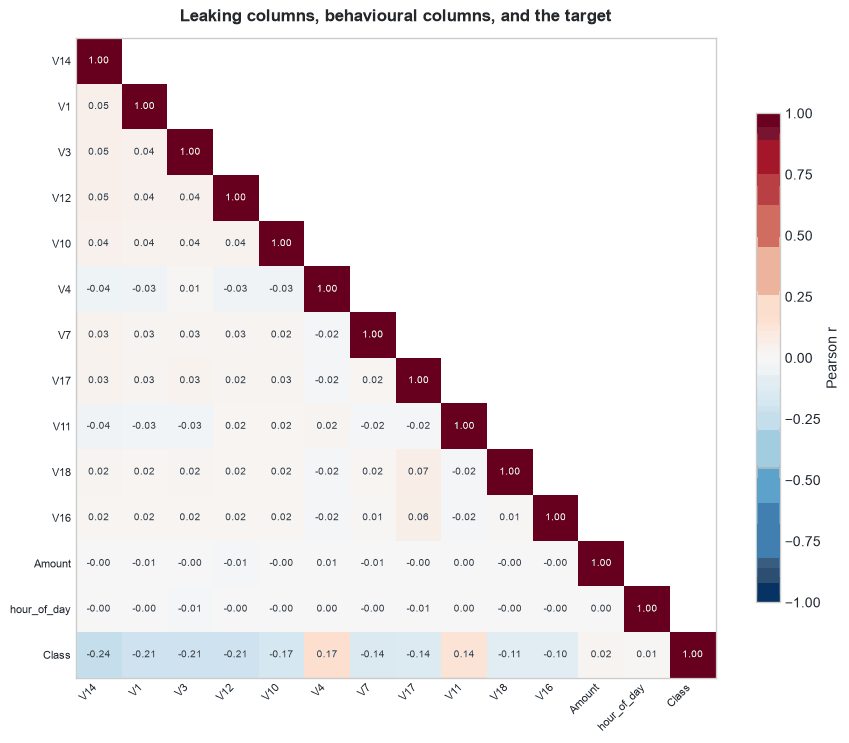

Linear correlation with Class
----------------------------------------------------
  V14            -0.241   (leaking)
  V3             -0.209   (leaking)
  V12            -0.209   (leaking)
  V1             -0.208   (leaking)
  V10            -0.172   (leaking)
  V4             +0.171   (leaking)
  V7             -0.142   (leaking)
  V17            -0.139   (leaking)
  V11            +0.139   (leaking)
  V18            -0.108   (leaking)
  V16            -0.103   (leaking)
  Amount         +0.024   (behavioural)
  hour_of_day    +0.012   (behavioural)

Note the ceiling: even the worst offender only reaches |r| ~ 0.24, because
Pearson r is bounded by the 0.5% prevalence. Correlation is the wrong lens
for a rare label, which is why section 5 uses single-feature AUC instead.


In [13]:
CORR_COLS = LEAKAGE_COLS + ["Amount", "hour_of_day", "Class"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.ma.masked_array(corr.values, mask=mask), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CORR_COLS, fontsize=8)
ax.grid(False)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.55 else "#2c3e50")
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
ax.set_title("Leaking columns, behavioural columns, and the target",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

target_corr = corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
print("Linear correlation with Class")
print("-" * 52)
for name, value in target_corr.items():
    tag = "leaking" if name in LEAKAGE_COLS else "behavioural"
    print(f"  {name:<14} {value:+.3f}   ({tag})")
print()
print("Note the ceiling: even the worst offender only reaches |r| ~ 0.24, because")
print("Pearson r is bounded by the 0.5% prevalence. Correlation is the wrong lens")
print("for a rare label, which is why section 5 uses single-feature AUC instead.")


## 11. Target Analysis <a id='target'></a>


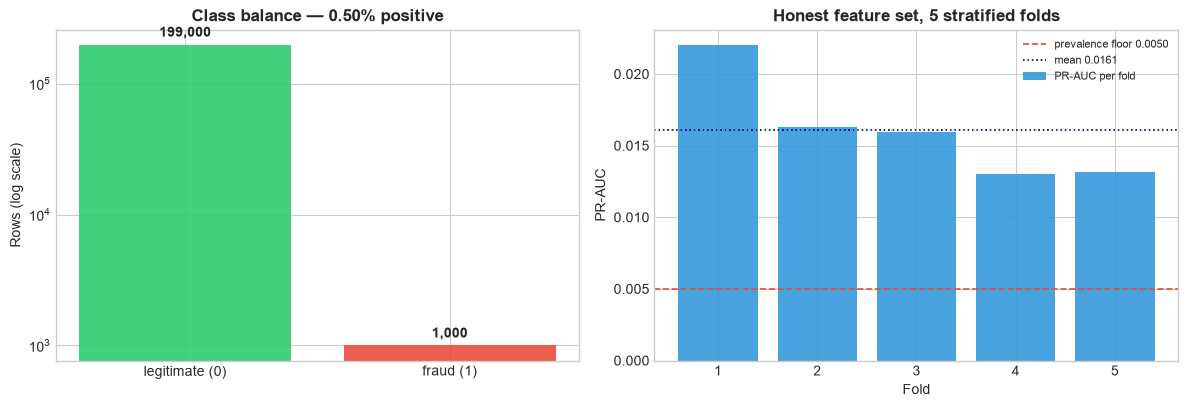

Fraud rate per validation fold: 0.5000%, 0.5000%, 0.5000%, 0.5000%, 0.5000%
Spread across folds: 0.0000% — stratification is doing its job.


In [14]:
counts = y.value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
bars = ax1.bar(["legitimate (0)", "fraud (1)"], counts.values,
               color=["#2ecc71", "#e74c3c"], alpha=0.9)
ax1.set_yscale("log")
ax1.set_ylabel("Rows (log scale)")
ax1.set_title(f"Class balance — {prevalence:.2%} positive", fontweight="bold")
for bar, value in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, value * 1.15, f"{value:,}",
             ha="center", fontsize=10, fontweight="bold")

folds = np.arange(1, len(pr) + 1)
ax2.bar(folds, pr, color="#3498db", alpha=0.9, label="PR-AUC per fold")
ax2.axhline(prevalence, color="#e74c3c", linestyle="--", linewidth=1.2,
            label=f"prevalence floor {prevalence:.4f}")
ax2.axhline(pr.mean(), color="navy", linestyle=":", linewidth=1.2,
            label=f"mean {pr.mean():.4f}")
ax2.set_xticks(folds)
ax2.set_xlabel("Fold")
ax2.set_ylabel("PR-AUC")
ax2.set_title("Honest feature set, 5 stratified folds", fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

fold_rates = [y.iloc[test].mean() for _, test in cv.split(X, y)]
print("Fraud rate per validation fold: " + ", ".join(f"{r:.4%}" for r in fold_rates))
print(f"Spread across folds: {max(fold_rates) - min(fold_rates):.4%} — "
      "stratification is doing its job.")


## 12. Evaluation Readiness <a id='evaluation'></a>

What a modelling notebook should carry forward from this audit.


In [15]:
print("Evaluation readiness checklist")
print("=" * 66)
print(f"Target                : {TARGET_COL}  ({prevalence:.2%} positive)")
print(f"Task                  : {MODELING_TASK}")
print(f"Metric                : {PRIMARY_METRIC}, ROC-AUC alongside")
print(f"Validation            : {VALIDATION_PLAN}")
print(f"Honest baseline       : PR-AUC {pr.mean():.4f} +/- {pr.std():.4f}, "
      f"ROC-AUC {roc.mean():.4f}")
print(f"Prevalence floor      : PR-AUC {prevalence:.4f}")
print()
print("Drop before fitting:")
print(f"  leaking     : {', '.join(LEAKAGE_COLS)}")
print(f"  degenerate  : {', '.join(DEGENERATE_COLS) or 'none'}")
print("  identifier  : transaction_id")
print("  redundant   : day_of_week (2 values only), and either Time or hour_of_day")
print()
print("Feature engineering this EDA earns:")
print("  is_night        = hour_of_day in {23, 0, 1, 2, 3}      # section 9")
print("  log_amount      = log1p(Amount)                        # section 8")
print("  amount_under_100 = Amount < 100                        # section 8")
print("  category_risk   = target-encode merchant_category inside each fold")
print()
print("Risk checks:")
print("  - re-run the section 5 audit after every feature you add; a single")
print("    leaking column silently restores the perfect score")
print("  - target-encode inside the fold, never before the split")
print("  - report PR-AUC against the prevalence floor, not against 0")


Evaluation readiness checklist
Target                : Class  (0.50% positive)
Task                  : classification
Metric                : PR-AUC (average precision), ROC-AUC alongside
Validation            : StratifiedKFold(5, shuffle=True, random_state=42)
Honest baseline       : PR-AUC 0.0161 +/- 0.0033, ROC-AUC 0.7373
Prevalence floor      : PR-AUC 0.0050

Drop before fitting:
  leaking     : V14, V1, V3, V12, V10, V4, V7, V17, V11, V18, V16
  degenerate  : is_weekend
  identifier  : transaction_id
  redundant   : day_of_week (2 values only), and either Time or hour_of_day

Feature engineering this EDA earns:
  is_night        = hour_of_day in {23, 0, 1, 2, 3}      # section 9
  log_amount      = log1p(Amount)                        # section 8
  amount_under_100 = Amount < 100                        # section 8
  category_risk   = target-encode merchant_category inside each fold

Risk checks:
  - re-run the section 5 audit after every feature you add; a single
    leaking colum

## 13. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above or drawn on a chart in it.

### Finding 1 — the PCA block is the label in disguise
Eleven of the twenty-eight `V` columns carry a class-conditional mean shift
between 1.46 and 3.51; `V14` alone reaches **AUC 0.992**. Stacked, they make the
classes **linearly separable**: the best-scoring legitimate row sits at
**−3.88** and the worst-scoring fraud row at **−1.30**, an empty corridor between
them, with the class means **8.39 standard deviations** apart. Every ranking
metric saturates there, **therefore** the advertised precision-recall problem does
not exist on those columns.

### Finding 2 — seventeen `V` columns are decoration
The unshifted components measure between **AUC 0.500 and 0.524** on their own —
inside the noise band for 1,000 positives. They pad the schema to look like the
real ULB dataset; they carry nothing.

### Finding 3 — the behavioural columns are the real benchmark
`Amount`, `hour_of_day` and `merchant_category` give 5-fold **PR-AUC 0.0161**
against a **0.0050** prevalence floor (**3.2×**) and **ROC-AUC 0.737**. The signal
is concentrated: hour 23 runs at **3.44%** fraud against **0.50%** overall, the
23:00–03:59 window runs **5.6×** the daytime rate, and merchant categories span
**0.079%** (grocery) to **1.23%** (electronics), a **15×** range.

### Finding 4 — two columns are broken outright
`is_weekend` is the constant `0` across all 200,000 rows, because the 48-hour
window starts mid-week and never reaches a weekend. `hour_of_day` and
`day_of_week` reproduce exactly from `Time` (**100%** agreement), and
`day_of_week` only ever takes the values 0 and 1.

### Finding 5 — fraud amounts are bimodal, which defeats a single threshold
Fraud has the **lower median** (\$11.59 vs \$33.21) and the **higher mean**
(\$110.10 vs \$67.83) at the same time, because the generator mixes 70% micro-test
amounts under \$100 with 30% large-ticket amounts. A "flag transactions over \$X"
rule therefore catches the wrong half whichever way it is set.

### Trade-offs, limitations, and caveats
- **Limitation — synthetic.** These are properties of `create_dataset.py`, not of
  card fraud. The value here is a known ground truth against which a leakage audit
  can be checked, not evidence about payments.
- **Trade-off — the honest feature set is weak on purpose.** Keeping only the
  behavioural columns costs almost all of the apparent performance. That is the
  correct trade: a saturated metric ranks nothing, so a low score with headroom is
  worth more than a perfect one without.
- **Caveat — correlation understates everything here.** At 0.5% prevalence Pearson
  *r* is mechanically bounded; the strongest leaking column still reads only
  **−0.241**. Use AUC or lift on rare labels, not *r*.
- **Caveat — one split, one model.** The 0.0161 figure is a single 5-fold
  logistic-regression result at one seed. It establishes that the behavioural
  columns beat the floor, not what the ceiling on them is.

### Next steps
- **Recommend** replacing the `V` block entirely for any benchmark use, and
  publishing the behavioural sub-problem as the headline task.
- Add a per-fold target encoding of `merchant_category` and an `is_night` flag, then
  re-measure PR-AUC against the 0.0161 baseline above.
- Try a gradient-boosted model on the three behavioural columns to see whether the
  `Amount` bimodality is worth a non-linear split; a linear model cannot use it.
- Regenerate the dataset with `is_weekend` removed and the fraud shifts reduced to
  ~0.5 sigma, which would make the PCA task non-trivial instead of unusable.
